## Device

In [1]:
shared_folder_Path = "/media/marina/01DB47DC6EBB7DC0/ThreeD/shared"[:-6]
path = '/media/marina/01DB47DC6EBB7DC0/ABONA_MEENA_ALL/0_Data/conp-dataset/projects/calgary-campinas/CC359/Raw-data/Single-channel/IM_MoCo/'
path_model= '/media/marina/01DB47DC6EBB7DC0/ThreeD/IDEA_2/zFINAL_ImMoCoArtifact_CC359data/1_Unet_InstanceNorm/'
import sys,os, glob, torch
import pickle
sys.path.insert(1,shared_folder_Path)
try:
    os.mkdir('')
except:
    pass

paths_train = glob.glob(path + "/train/*")
paths_test  = glob.glob(path + "/test/*")
paths_test_low = [p for p in paths_test if ('motion_5' in p)]
paths_test_mid = [p for p in paths_test if ('motion_15' in p)]
paths_test_hgh = [p for p in paths_test if ('motion_25' in p)]
len(paths_train), len(paths_test_low), len(paths_test_hgh),len(paths_test)

(3, 400, 400, 1200)

## Import

In [2]:
%load_ext autoreload
%autoreload 2

from torcheval.metrics import PeakSignalNoiseRatio
import torch
from torch.optim import lr_scheduler
from torch.autograd import Variable
import numpy as np
import random
from tqdm import tqdm
import nibabel as nib
from shared.plot import plot_2_Imgs, plot_3_Imgs, plot_4_Imgs, plot_Img
from torch.utils.data import Dataset, DataLoader
from shared.ssim import SSIM
ssim_calc = SSIM()
from torchvision import transforms
import torch.nn.functional as F
from scipy import ndimage
sys.path.append('src/')


def get_n_params( model):
    pp=0
    for p in list(model.parameters()):
        nn=1
        for s in list(p.size()):
            nn = nn*s
        pp += nn

    return pp


# Deterministic for spectral norm
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
def init_seeds(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(0)
    # no change in alg
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.use_deterministic_algorithms(True)
init_seeds(42)

## Data

In [3]:
import torch
from torch.fft import fftn, fftshift, ifftn, ifftshift
import torchvision
import torch.nn.functional as F

vflip = lambda a: torchvision.transforms.functional.vflip(a)
hflip = lambda a: torchvision.transforms.functional.hflip(a)


def pad(arr,pad_to):

    arr = F.pad( arr, ((pad_to-arr.shape[1])//2, (pad_to-arr.shape[1])//2,
                       (pad_to-arr.shape[0])//2, (pad_to-arr.shape[0])//2), mode='constant', value=0)

    return arr


def real_2_complex_shape(arr):
    if(len(arr.shape)==4 and arr.shape[1]==2):
        k_out2 = arr[:,0:1,:,:] + 1j* arr[:,1:2,:,:]
    if(len(arr.shape)==3 and arr.shape[0]==2):
        k_out2 = arr[0:1,:,:] + 1j* arr[1:2,:,:]

    return k_out2

def print_mini_maxi(arr):
    print(arr.min(), arr.max())
    
def FFT(x):
    return fftshift(fftn(ifftshift(x, dim=(-2, -1)), dim=(-2, -1)), dim=(-2, -1))


def IFFT(x):
    return ifftshift(ifftn(fftshift(x, dim=(-2, -1)), dim=(-2, -1)), dim=(-2, -1))


def norm_0_1(arr):
    arr = ((arr - arr.min()) / (arr.max()-arr.min()))
    return arr
def norm_1_1(arr):
    arr = ((arr - arr.min()) / (arr.max()-arr.min()))*2-1
    return arr


def normImg(x: torch.Tensor):

    # group norm
    c, h, w = x.shape
    x = x.reshape(1, c // 1 * h * w)
  
    mean = x.mean(dim=2).view(1, 1, 1)
    std = x.std(dim=2).view(1, 1, 1)
    x = x.view(c, h, w)
  
  
    return (x - mean) / std, mean, std


def convert_polar_to_cylindrical( magnitude, phase):

    real = magnitude * torch.cos(phase)
    imag = magnitude * torch.sin(phase)
    return real, imag


def convert_cylindrical_to_polar(real,imag):

    mag = (real ** 2 + imag ** 2) ** (0.5)
    phase = torch.atan2(imag, real)
    phase[phase.ne(phase)] = 0.0  # remove NANs if any
    return mag, phase

def normalized_complex_mag(arr):

    mag, phase = convert_cylindrical_to_polar(arr.real,arr.imag)
    normalized_magnitude = (mag - torch.mean(mag)) / (torch.std(mag))
    real,imag = convert_polar_to_cylindrical(normalized_magnitude,phase)
    normed = real+1j*imag 

    return normed


In [4]:
def preprocess(kspace, k_space_artifact,Main_Artifact_path,mask):

    # IFFT
    image_Complex = IFFT(kspace)
    image_artifact_Complex = IFFT(k_space_artifact)
    
    # Img
    image = image_Complex.abs()
    image_artifact = image_artifact_Complex.abs()
    
    # Norm img
    image = norm_0_1(image)
    image_artifact = norm_0_1(image_artifact)
    

    # View
    kspace = torch.view_as_real(kspace)
    kspace = torch.moveaxis(kspace,-1,0)
    k_space_artifact = torch.view_as_real(k_space_artifact)
    k_space_artifact = torch.moveaxis(k_space_artifact,-1,0)
    image_Complex = torch.view_as_real(image_Complex)
    image_Complex = torch.moveaxis(image_Complex,-1,0)
    image_artifact_Complex = torch.view_as_real(image_artifact_Complex)
    image_artifact_Complex = torch.moveaxis(image_artifact_Complex,-1,0)


    return  {"Arr":image[None,...],
             "Arr_Complex":image_Complex,
                "Art":image_artifact[None,...],
             "Art_Complex":image_artifact_Complex,
                "K_Arr":kspace,
                "K_Art":k_space_artifact,
                'path':Main_Artifact_path,
            }

class MRIDataset(Dataset):
    def __init__(self, imgs_paths):
        self.imgs_paths = imgs_paths
    def __len__(self):
        return len(self.imgs_paths)
    def __getitem__(self, index):

        Main_Artifact_path = self.imgs_paths[index]
        kspace,k_space_artifact,mask = torch.load(Main_Artifact_path, weights_only=False)
        return  preprocess(kspace,k_space_artifact,Main_Artifact_path, mask)

3 1200
/media/marina/01DB47DC6EBB7DC0/ABONA_MEENA_ALL/0_Data/conp-dataset/projects/calgary-campinas/CC359/Raw-data/Single-channel/IM_MoCo//test/e14258s3_P76800.7._slice_78_motion_25.pt
PSNR:  25.53675651550293


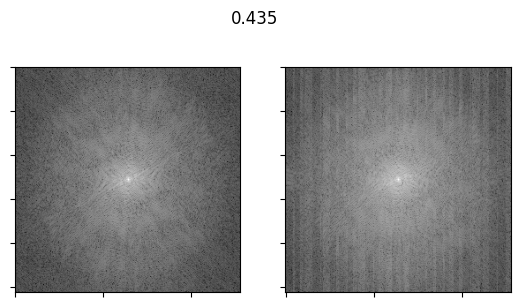

PSNR:  18.520206451416016


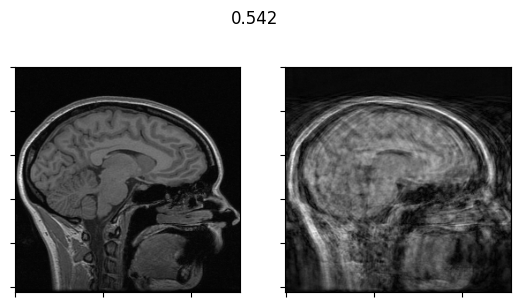

In [5]:
#dataset
dataset_train = MRIDataset(paths_train)
dataset_val = MRIDataset(paths_test)
print(len(dataset_train), len(dataset_val))

#dataloaders
batch_size = 1
dataloaders = dict()
dataloaders['train'] = DataLoader(dataset_train, batch_size=batch_size,
                                   shuffle=True, pin_memory=True)
dataloaders['val'] = DataLoader(dataset_val, batch_size=batch_size,
                                shuffle=False, pin_memory=True)
sample = dataset_val[random.randint(0,len(dataset_val))]

device = 'cuda'    
with torch.no_grad():
    print(sample['path'])
    Arr = sample['Arr'][None].to(device)
    Art = sample['Art'][None].to(device)
    
    K_Art = sample['K_Art'].to(device)
    K_Arr = sample['K_Arr'].to(device)
    K_Art = torch.view_as_complex(torch.moveaxis(K_Art,0,-1))
    K_Arr = torch.view_as_complex(torch.moveaxis(K_Arr,0,-1))
    
    plot_2_Imgs(K_Arr.abs().add(1e-9).log(),K_Art.abs().add(1e-9).log())
    plot_2_Imgs(Arr,Art)

## Model

/tmp/ipykernel_12331/2348280506.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load('/media/marina/01DB47DC6EBB7DC0/ThreeD/IDEA_2/zFINAL_ImMoCoArtifact_CC

8556994
51
ta/Single-channel/IM_MoCo//test/e14258s3_P76800.7._slice_118_motion_25.pt
BLUR:  tensor([0.4328], device='cuda:0')


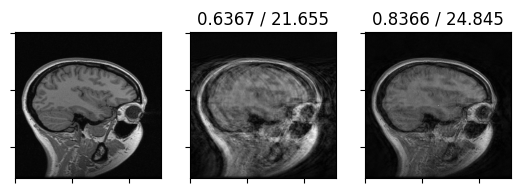

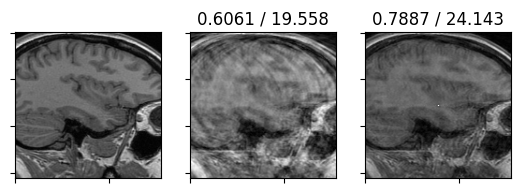

In [6]:
from unet_code import *
model = K_U_Net().cuda()
model = torch.load('/media/marina/01DB47DC6EBB7DC0/ThreeD/IDEA_2/zFINAL_ImMoCoArtifact_CC359data/Ablation/0_KUnet_InstanceNorm/29model_lossImg.pt')
print(get_n_params(model))
p = random.randint(0,len(dataset_val))#65#285#457#-1116#-178#51
print(p)

sample= dataset_val[p]
print(sample['path'][105:])
device = 'cuda' 

with torch.no_grad():
    K_Art = sample['K_Art'][None].to(device)
    
    k_out, Real_out = model(K_Art)    
    
    from shared.CreateRoffetBlur import CreteRoffetBlur
    b  = CreteRoffetBlur(2)
    print("BLUR: ",b(Real_out))
    
    plot_3_Imgs(sample['Arr'][0],sample['Art'][0],Real_out[0,0])
    plot_3_Imgs(sample['Arr'][:,50:-50,50:-50],sample['Art'][:,50:-50,50:-50],Real_out[:,:,50:-50,50:-50])


torch.Size([222, 236, 256, 2])
torch.Size([222, 236, 256])
torch.Size([256, 236, 256])
torch.Size([1, 2, 256, 256])
tensor([0.4225], device='cuda:0')
PSNR:  34.070377349853516


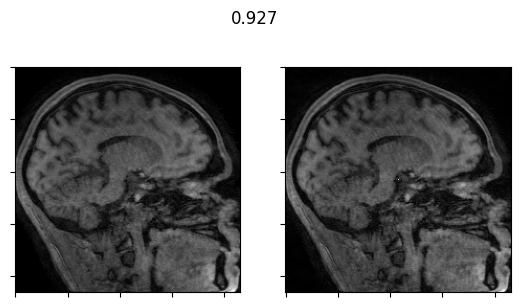

In [11]:
from shared.CreateRoffetBlur import CreteRoffetBlur
b  = CreteRoffetBlur(2)

input_img_3DNuFFT = torch.load('/media/marina/01DB47DC6EBB7DC0/ABONA_MEENA_ALL/0_Data/PMoCo3D/input_img_3DNuFFT.pt','cpu',weights_only=False)
print(input_img_3DNuFFT.shape)
input_img_3DNuFFT = torch.view_as_complex(input_img_3DNuFFT)
print(input_img_3DNuFFT.shape)
input_img_3DNuFFT = F.pad( input_img_3DNuFFT, (0, 0,0,0, 17, 17), mode='constant', value=0)
print(input_img_3DNuFFT.shape)

t = 130
Art =input_img_3DNuFFT[:,t]
Art = torch.tensor(ndimage.rotate(Art, -90))


K_Art = FFT(Art)
K_Art = torch.view_as_real(K_Art)
K_Art = torch.moveaxis(K_Art,-1,0)[None].cuda()
print(K_Art.shape)

with torch.no_grad():
    
    k_out, Real_out = model(K_Art) 
    print(b(Real_out))

    
    #plot_Img(Art[0,0,20:-20,20:-20],rotate=False,title= "blur: " + str(float(b(Art)))[:5])
    plot_2_Imgs(norm_0_1(abs(Art))[20:-20,20:-20],Real_out[0,0,20:-20,20:-20],rotate=False)    

## Loss & Optimization

In [9]:
from shared.GradualWarmupSchedulerFile import *
from shared.ssim import SSIM
import torch.nn as nn

SSIM_criterion = SSIM().cuda()
msee = nn.MSELoss()
learning_rate = 10**-4
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

## Training

In [10]:
def normLoss(x: torch.Tensor):
    b, c, h, w = x.shape
    x = x.view(b, 2, c // 2 * h * w)
  
    mean = x.mean(dim=2).view(b, 2, 1, 1)
    std = x.std(dim=2).view(b, 2, 1, 1)
    x = x.view(b, c, h, w)
    return (x - mean) / std#, mean, std

def complex_mse_loss(y_true, y_pred):
    y_true = normLoss(y_true)
    y_pred = normLoss(y_pred)
    y_true = y_true[:,0:1,:,:] + 1j * y_true[:,1:2,:,:]
    y_pred = y_pred[:,0:1,:,:] + 1j * y_pred[:,1:2,:,:]
    msee_real = msee(y_true.real,y_pred.real)
    msee_complex = msee(y_true.imag,y_pred.imag)
    
    return msee_real + msee_complex

In [ ]:
num_epochs = 50

for epoch in range(num_epochs):
    model.train()
    ssim_all = 0 ;  K_ssim_all = 0 ; mse_all = 0

    pbar_train = tqdm(enumerate(dataloaders['train']), total=len(dataloaders['train']), position=0, leave=True)
    for (i, data) in pbar_train:

        optimizer.zero_grad()
    
        Arr = Variable(data['Arr']).to(device)
        K_Art = Variable(data['K_Art']).to(device)
        K_Arr = Variable(data['K_Arr']).to(device)
        
        k_correct, real_correct = model(K_Art)
               
        loss_train = 1- SSIM_criterion(real_correct, Arr)#+\
                     #complex_mse_loss(k_correct,K_Arr)+\
                     #1-SSIM_criterion(normLoss(k_correct),normLoss(K_Arr))
                     #(1- SSIM_criterion(real_correct2, Arr))+\
        
        loss_train.backward()
        optimizer.step()

        ssim_all += SSIM_criterion(real_correct, Arr).cpu().detach()
        mse_all += complex_mse_loss(k_correct,K_Arr).cpu().detach()
        K_ssim_all += SSIM_criterion(normLoss(k_correct),normLoss(K_Arr)).cpu().detach() 
        
        if(i%10==0):
            if((i==0) and (epoch==0)):
                file1 = open(path_model + "log.txt", "w")
            else:
                file1 = open(path_model + "log.txt", "a")
            file1.write("Epoch: " + str(epoch)+ "  , step: " + str(i) + "  , SSIM: " + str(float(ssim_all/(i+1)))+ "  , MSE: " + str(float(mse_all/(i+1))) + "  , K_ssim_all: " + str(float(K_ssim_all/(i+1))) + "\n")
            file1.close()

    print("Train SSIM: " ,ssim_all/len(pbar_train))
    print("Train mse_all: " ,mse_all/len(pbar_train))
    print("Train K_ssim_all: " ,K_ssim_all/len(pbar_train))
    print( "epoch: " , epoch, 'lr: '+ str(optimizer.param_groups[0]['lr'])+ "\n")

    file1 = open(path_model + "log.txt", "a")
    file1.write("Epoch: " + str(epoch)+ "  , Train: " + "  , SSIM: " + str(float(ssim_all/len(pbar_train))) + "\n"+ 'lr: '+ str(optimizer.param_groups[0]['lr'])+ "\n")
    file1.close()

    torch.save(model, path_model+"/"+str(epoch)+"model.pt")
    
    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~`
    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~`
    with torch.no_grad():
      ssim_all = 0
      ssim_all2 = 0
      pbar_test = tqdm(enumerate(dataloaders['val']), total=len(dataloaders['val']), position=0, leave=True)
      for (i, datatest) in pbar_test:

            Img_arr = Variable(datatest['Arr']).to(device)
            K_Art = Variable(datatest['K_Art']).to(device)
            
            k_correct, real_correct = model(K_Art)
                
            ssim_all += SSIM_criterion(real_correct, Img_arr).cpu().detach()
         
      print("Test SSIM: " ,ssim_all/len(pbar_test))

      file1 = open(path_model + "log.txt", "a")
      file1.write("Epoch: " + str(epoch)+ "  , Test: " + "  , SSIM: " + str(float(ssim_all/len(pbar_test))) + "\n")
      file1.close()

In [7]:
from torcheval.metrics import PeakSignalNoiseRatio
metric = PeakSignalNoiseRatio()
from shared.ssim import SSIM
SSIM_criterion = SSIM().cuda()
from shared.CreateRoffetBlur import CreteRoffetBlur
b  = CreteRoffetBlur(2)

with torch.no_grad():
  ssim_all = []
  psnr_bef=[]
  ssim_all_bef = []
  psnr=[]
  BLUR = []
  BLUR_BEF = []
  pbar_test = tqdm(enumerate(dataloaders['val']), total=len(dataloaders['val']), position=0, leave=True)
  for (i, datatest) in pbar_test:

        Art = Variable(datatest['Art']).to(device)
        K_Art = Variable(datatest['K_Art']).to(device)
        Arr = Variable(datatest['Arr'].to(device))

        _,outputs_test = model(K_Art)

        ssim_all .append(  float(SSIM_criterion(outputs_test, Arr).cpu().detach()))
        ssim_all_bef .append( float(SSIM_criterion(Art, Arr).cpu().detach()))

        metric = PeakSignalNoiseRatio()
        metric.update(outputs_test, Arr)
        psnr.append( float(metric.compute()))

        metric = PeakSignalNoiseRatio()
        metric.update(Art, Arr)
        psnr_bef.append( float(metric.compute()))

        BLUR .append( torch.sum(b(outputs_test)).cpu().detach())
        BLUR_BEF  .append( torch.sum(b(Art)).cpu().detach())

100%|██████████| 1200/1200 [01:27<00:00, 13.64it/s]


In [9]:
print("ssim std :",np.std(ssim_all), "ssim mean :",np.mean(ssim_all))

print("psnr std :",np.std(psnr), "psnr mean :",np.mean(psnr))

print("Blur std :",np.std(BLUR), "Blur mean :",np.mean(BLUR))

ssim std : 0.06380921407300595 ssim mean : 0.9135570030411084
psnr std : 5.546008486879451 psnr mean : 30.663144011497497
Blur std : 0.020830858 Blur mean : 0.42229933
